<Figure size 1000x800 with 0 Axes>

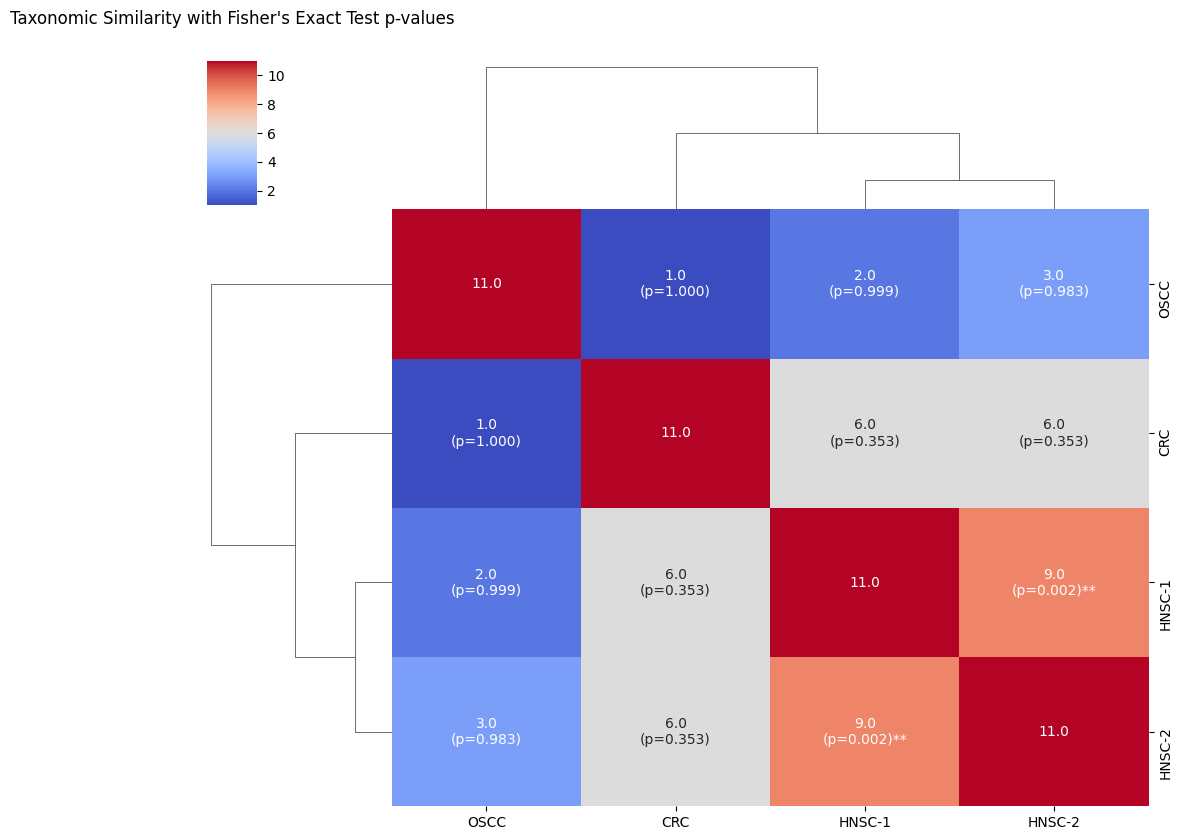

P-value Matrix:
                 CRC          OSCC        HNSC-1        HNSC-2
CRC     4.006179e-07  9.999688e-01  3.534123e-01  3.534123e-01
OSCC    9.999688e-01  4.006179e-07  9.987084e-01  9.829541e-01
HNSC-1  3.534123e-01  9.987084e-01  4.006179e-07  1.776340e-03
HNSC-2  3.534123e-01  9.829541e-01  1.776340e-03  4.006179e-07


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. 샘플 데이터 준비 (리뷰어 답변대로 Top 11 종 사용)
data = {
    "CRC": ["Bacteroides", "Cronobacter", "Enterobacter", "Erwinia", "Klebsiella", "Pantoea", "Pseudomonas", "Serratia", "Shewanella", "Vibrio", "Yersinia"],
    "OSCC": ["Bacillus", "Bacteroides", "Blattabacterium", "Clostridium", "Flavobacterium", "Fusobacterium", "Lactobacillus", "Paenibacillus", "Porphyromonas", "Prevotella", "Streptococcus"],
    "HNSC-1": ["Acinetobacter", "Enterobacter", "Erwinia", "Fusobacterium", "Klebsiella", "Pantoea", "Pectobacterium", "Providencia", "Serratia", "Streptococcus", "Yersinia"],
    "HNSC-2": ["Acinetobacter", "Bacillus", "Enterobacter", "Fusobacterium", "Klebsiella", "Pantoea", "Pectobacterium", "Serratia", "Streptococcus", "Vibrio", "Yersinia"]
}

# 분석에 사용된 전체 유니크 종 리스트 (Universe 크기 설정용)
all_species = set([sp for species_list in data.values() for sp in species_list])
N = len(all_species) # 전체 종의 총합 (Contingency table의 전체 모집단 크기)

sample_names = list(data.keys())
overlap_matrix = pd.DataFrame(index=sample_names, columns=sample_names, dtype=int)
p_value_matrix = pd.DataFrame(index=sample_names, columns=sample_names, dtype=float)

# 2. Fisher's Exact Test 수행 및 p-value 계산
for s1 in sample_names:
    for s2 in sample_names:
        set1 = set(data[s1])
        set2 = set(data[s2])
        
        intersection = len(set1 & set2)
        only_s1 = len(set1 - set2)
        only_s2 = len(set2 - set1)
        neither = N - (intersection + only_s1 + only_s2)
        
        # Contingency Table 구성
        # [[both, only_s1], [only_s2, neither]]
        table = [[intersection, only_s1], [only_s2, neither]]
        
        # Fisher's Exact Test (Alternative='greater'는 유사성을 검정함)
        _, p_val = fisher_exact(table, alternative='greater')
        
        overlap_matrix.loc[s1, s2] = intersection
        p_value_matrix.loc[s1, s2] = p_val

# 3. 시각화 (Dendrogram + Heatmap)
# 계층적 클러스터링 (답변서에 명시한 'average' linkage 사용)
row_linkage = linkage(overlap_matrix, method='average')

# 히트맵에 표시할 텍스트 (Overlap 수치와 p-value 별표 함께 표시)
annot_matrix = overlap_matrix.copy().astype(str)
for s1 in sample_names:
    for s2 in sample_names:
        p = p_value_matrix.loc[s1, s2]
        if s1 == s2: 
            annot_matrix.loc[s1, s2] = f"{overlap_matrix.loc[s1, s2]}"
        else:
            star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            annot_matrix.loc[s1, s2] = f"{overlap_matrix.loc[s1, s2]}\n(p={p:.3f}){star}"

# 플롯 그리기
plt.figure(figsize=(10, 8))
g = sns.clustermap(overlap_matrix, 
                   row_linkage=row_linkage, 
                   col_linkage=row_linkage, 
                   annot=annot_matrix, 
                   fmt="", 
                   cmap='coolwarm', 
                   figsize=(10, 8))

plt.title("Taxonomic Similarity with Fisher's Exact Test p-values", y=1.2)
plt.show()

# 4. p-value 결과 출력 (답변서 기재용)
print("P-value Matrix:")
print(p_value_matrix)

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from scipy.cluster.hierarchy import linkage

# 1. 데이터 준비 (Top 11 종 기준)
data = {
    "CRC": ["Bacteroides", "Cronobacter", "Enterobacter", "Erwinia", "Klebsiella", "Pantoea", "Pseudomonas", "Serratia", "Shewanella", "Vibrio", "Yersinia"],
    "OSCC": ["Bacillus", "Bacteroides", "Blattabacterium", "Clostridium", "Flavobacterium", "Fusobacterium", "Lactobacillus", "Paenibacillus", "Porphyromonas", "Prevotella", "Streptococcus"],
    "HNSC-1": ["Acinetobacter", "Enterobacter", "Erwinia", "Fusobacterium", "Klebsiella", "Pantoea", "Pectobacterium", "Providencia", "Serratia", "Streptococcus", "Yersinia"],
    "HNSC-2": ["Acinetobacter", "Bacillus", "Enterobacter", "Fusobacterium", "Klebsiella", "Pantoea", "Pectobacterium", "Serratia", "Streptococcus", "Vibrio", "Yersinia"]
}

# 분석에 사용된 전체 유니크 종 리스트 (Universe 크기)
all_species = set([sp for species_list in data.values() for sp in species_list])
N = len(all_species)

sample_names = list(data.keys())
overlap_matrix = pd.DataFrame(index=sample_names, columns=sample_names, dtype=int)
p_value_matrix = pd.DataFrame(index=sample_names, columns=sample_names, dtype=float)

# 2. Fisher's Exact Test 및 데이터 계산
for s1 in sample_names:
    for s2 in sample_names:
        set1 = set(data[s1])
        set2 = set(data[s2])
        
        intersection = len(set1 & set2)
        only_s1 = len(set1 - set2)
        only_s2 = len(set2 - set1)
        neither = N - (intersection + only_s1 + only_s2)
        
        # Contingency Table: [[both, only_s1], [only_s2, neither]]
        table = [[intersection, only_s1], [only_s2, neither]]
        
        # Fisher's Exact Test (유사성 검정: alternative='greater')
        _, p_val = fisher_exact(table, alternative='greater')
        
        overlap_matrix.loc[s1, s2] = intersection
        p_value_matrix.loc[s1, s2] = p_val

# 3. CSV 파일로 내보내기 (Zenodo/GitHub 업로드용)
overlap_matrix.to_csv("processed__taxonomic_overlap_matrix.csv")
p_value_matrix.to_csv("processed__taxonomic_p_value_matrix.csv")

print("두 개의 CSV 파일이 성공적으로 생성되었습니다:")
print("1. processed__taxonomic_overlap_matrix.csv")
print("2. processed__taxonomic_p_value_matrix.csv")

# 결과 확인 (화면 출력)
print("\n--- P-value Matrix ---")
print(p_value_matrix)

두 개의 CSV 파일이 성공적으로 생성되었습니다:
1. processed__taxonomic_overlap_matrix.csv
2. processed__taxonomic_p_value_matrix.csv

--- P-value Matrix ---
                 CRC          OSCC        HNSC-1        HNSC-2
CRC     4.006179e-07  9.999688e-01  3.534123e-01  3.534123e-01
OSCC    9.999688e-01  4.006179e-07  9.987084e-01  9.829541e-01
HNSC-1  3.534123e-01  9.987084e-01  4.006179e-07  1.776340e-03
HNSC-2  3.534123e-01  9.829541e-01  1.776340e-03  4.006179e-07
